
# 作業：模型擬合、評估與超參數調校（簡化練習版）

本作業使用 `winequality.csv` 作為練習資料集，目標是用紅酒的化學特徵預測紅酒品質是否達到「較好」等級。

請將 `winequality.csv` 與本 notebook 放在同一個資料夾後，再依序執行每個 cell。

---

## 本作業練習重點

這份作業根據原本的 `4.ipynb` 內容簡化而來。每個知識點都會提到，但同一類型的方法只保留一個主要實作，避免一次放入太多工具造成混淆。

| 原教材知識點 | 本作業簡化方式 |
|---|---|
| 一般機器學習流程 | 保留：讀取資料、建立目標、切分資料、訓練模型、評估模型 |
| Pipeline | 保留：用 `Pipeline` 串接標準化、特徵選取與模型 |
| 特徵選取 | 保留：使用 `SelectKBest` 選出代表性特徵 |
| 過擬合與欠擬合 | 保留：透過訓練分數、測試分數與學習曲線觀察 |
| 評估指標 | 主要使用：Accuracy；搭配混淆矩陣輔助理解 |
| P-R 曲線與 ROC 曲線 | 主要實作 ROC 曲線；P-R 曲線以概念方式提到 |
| 手動調整、Grid Search、Randomized Search | 主要實作 `GridSearchCV`；另外說明三者差異 |

---

## 作業情境

原始資料的 `quality` 是 3 到 8 之間的分數。為了讓作業變簡單，本作業把它轉成二元分類問題：

\[
\text{good\_quality} =
\begin{cases}
1, & \text{quality} \ge 6 \\
0, & \text{quality} < 6
\end{cases}
\]

也就是說：

- `good_quality = 1`：品質分數大於或等於 6，視為較好品質
- `good_quality = 0`：品質分數小於 6，視為普通或較低品質



# 1. 匯入套件與基本設定

本作業只使用一個代表性的分類模型：`LogisticRegression`。

原因：

1. 它適合教學，模型概念相對簡單。
2. 它可以輸出預測機率，方便後面畫 ROC 曲線。
3. 它有重要超參數 `C`，可以示範正則化強度與超參數調校。


In [1]:

# ============================================================
# 1. 匯入套件與基本設定
# ============================================================

# 忽略部分警告訊息，讓教學輸出比較乾淨
import warnings
warnings.filterwarnings("ignore")

# 資料處理
import numpy as np
import pandas as pd

# 視覺化
import matplotlib.pyplot as plt

# 資料切分與交叉驗證
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV

# 建立 Pipeline
from sklearn.pipeline import Pipeline

# 前處理與特徵選取
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# 模型
from sklearn.linear_model import LogisticRegression

# 評估指標與視覺化工具
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# 設定中文字型顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# 讓表格顯示更多欄位，方便檢查結果
pd.set_option("display.max_columns", 30)



# 2. 讀取資料與檢查資料

請先確認資料是否正確讀入。

這份 CSV 使用分號 `;` 分隔欄位，所以讀取時需要加上：

```python
sep=";"
```


In [2]:

# ============================================================
# 2. 讀取資料與檢查資料
# ============================================================

# 請確認 winequality.csv 與這份 notebook 放在同一個資料夾
df = pd.read_csv("winequality.csv", sep=";")

# 查看資料大小
print("資料筆數與欄位數：")
print(df.shape)

# 查看前五筆資料
print("\n前五筆資料：")
display(df.head())

# 查看每個欄位是否有缺失值
print("\n每個欄位的缺失值數量：")
print(df.isna().sum())

# 查看 quality 的原始分布
print("\n原始 quality 分布：")
print(df["quality"].value_counts().sort_index())


資料筆數與欄位數：
(1599, 12)

前五筆資料：


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



每個欄位的缺失值數量：
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

原始 quality 分布：
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64



# 3. 建立二元分類目標

原本的 `quality` 是多個等級。為了讓作業聚焦在「模型流程與評估」，這裡改成二元分類問題。

\[
\text{good\_quality}=1 \quad \text{代表 quality} \ge 6
\]

\[
\text{good\_quality}=0 \quad \text{代表 quality} < 6
\]

## 請回答

1. 這個資料集轉成二元分類後，兩個類別是否大致平衡？
2. 如果類別非常不平衡，只看 Accuracy 可能會有什麼問題？


二元分類目標 good_quality 的數量分布：
good_quality
0    744
1    855
Name: count, dtype: int64

二元分類目標 good_quality 的比例分布：
good_quality
0    0.465291
1    0.534709
Name: proportion, dtype: float64


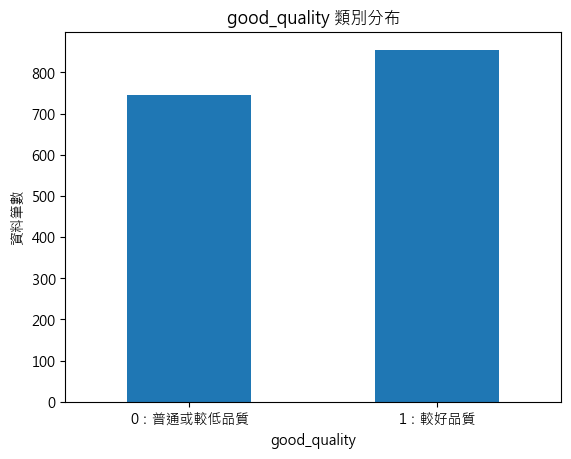

In [3]:

# ============================================================
# 3. 建立二元分類目標
# ============================================================

# 建立新的目標欄位：good_quality
# quality >= 6 視為較好品質，標記為 1
# quality < 6 視為普通或較低品質，標記為 0
df["good_quality"] = (df["quality"] >= 6).astype(int)

print("二元分類目標 good_quality 的數量分布：")
print(df["good_quality"].value_counts().sort_index())

print("\n二元分類目標 good_quality 的比例分布：")
print(df["good_quality"].value_counts(normalize=True).sort_index())

# 用長條圖檢查類別分布
ax = df["good_quality"].value_counts().sort_index().plot(kind="bar")
ax.set_title("good_quality 類別分布")
ax.set_xlabel("good_quality")
ax.set_ylabel("資料筆數")
ax.set_xticklabels(["0：普通或較低品質", "1：較好品質"], rotation=0)
plt.show()



# 4. 切分特徵與目標，並切分訓練集與測試集

在機器學習流程中，測試集應該保留到最後評估模型使用。

本作業使用：

- 80% 作為訓練集
- 20% 作為測試集

因為這是分類問題，所以使用 `stratify=y`，讓訓練集與測試集中的類別比例盡量接近原始資料。


In [4]:

# ============================================================
# 4. 切分特徵與目標，並切分訓練集與測試集
# ============================================================

# X：模型要使用的輸入特徵
# 注意：quality 是原始分數，good_quality 是答案欄位，兩者都不能放進 X
X = df.drop(columns=["quality", "good_quality"])

# y：模型要預測的目標
y = df["good_quality"]

# 切分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("訓練集 X_train：", X_train.shape)
print("測試集 X_test：", X_test.shape)
print("訓練集 y_train：", y_train.shape)
print("測試集 y_test：", y_test.shape)


訓練集 X_train： (1279, 11)
測試集 X_test： (320, 11)
訓練集 y_train： (1279,)
測試集 y_test： (320,)



# 5. 使用 Pipeline 建立模型流程

Pipeline 可以把多個步驟串在一起，讓流程更清楚，也能降低資料洩漏的風險。

本作業的 Pipeline 有三個步驟：

1. `StandardScaler`：標準化特徵
2. `SelectKBest`：選出與目標比較相關的前 `k` 個特徵
3. `LogisticRegression`：訓練分類模型

## 為什麼要標準化？

Logistic Regression 會受到特徵尺度影響。不同欄位的數值範圍差很多時，標準化可以讓模型訓練更穩定。

## 為什麼要特徵選取？

特徵選取可以讓學生觀察「不是所有欄位都一定要使用」。在這裡我們先固定選出 5 個特徵，保持作業簡單。


In [5]:

# ============================================================
# 5. 使用 Pipeline 建立模型流程
# ============================================================

model_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=5)),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# 訓練模型
model_pipeline.fit(X_train, y_train)

print("Pipeline 訓練完成。")


Pipeline 訓練完成。



# 6. 評估模型：Accuracy 與混淆矩陣

本作業主要使用 Accuracy 作為代表性指標。

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

其中：

- TP：實際為 1，模型也預測為 1
- TN：實際為 0，模型也預測為 0
- FP：實際為 0，但模型預測為 1
- FN：實際為 1，但模型預測為 0

雖然 Accuracy 很直覺，但只看 Accuracy 不一定足夠，所以本作業也會畫出混淆矩陣，觀察模型錯在哪裡。

## 請回答

1. 訓練集準確率與測試集準確率是否差很多？
2. 如果訓練集分數很高，但測試集分數明顯較低，可能代表什麼問題？


訓練集 Accuracy： 0.7342
測試集 Accuracy： 0.7844

SelectKBest 選出的特徵：
Index(['volatile acidity', 'total sulfur dioxide', 'density', 'sulphates',
       'alcohol'],
      dtype='str')


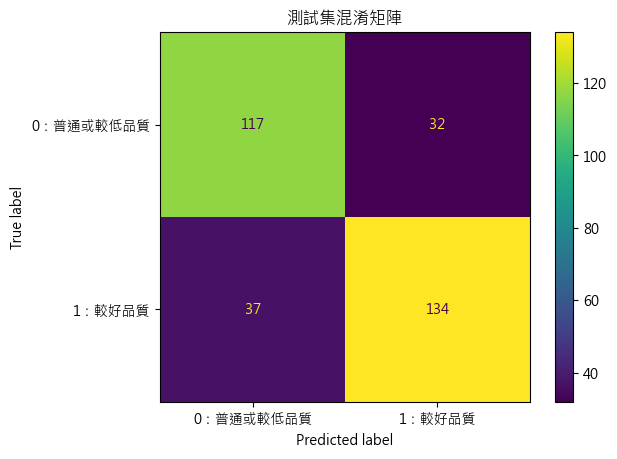

In [6]:

# ============================================================
# 6. 評估模型：Accuracy 與混淆矩陣
# ============================================================

# 對訓練集與測試集進行預測
train_pred = model_pipeline.predict(X_train)
test_pred = model_pipeline.predict(X_test)

# 計算 Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("訓練集 Accuracy：", round(train_accuracy, 4))
print("測試集 Accuracy：", round(test_accuracy, 4))

# 顯示模型選到哪些特徵
selected_mask = model_pipeline.named_steps["select"].get_support()
selected_features = X_train.columns[selected_mask]

print("\nSelectKBest 選出的特徵：")
print(selected_features)

# 繪製混淆矩陣
ConfusionMatrixDisplay.from_estimator(
    model_pipeline,
    X_test,
    y_test,
    display_labels=["0：普通或較低品質", "1：較好品質"]
)
plt.title("測試集混淆矩陣")
plt.show()



# 7. 過擬合與欠擬合：使用學習曲線觀察

原教材同時介紹學習曲線與驗證曲線。本作業為了簡化，主要實作「學習曲線」。

## 學習曲線 Learning Curve

學習曲線的橫軸是訓練資料量，縱軸是模型分數。它可以協助我們觀察：

- 增加訓練資料後，驗證分數是否還會上升
- 訓練分數與驗證分數是否差距很大
- 模型是否可能過擬合或欠擬合

## 驗證曲線 Validation Curve

驗證曲線的橫軸是某一個超參數，例如 Logistic Regression 的 `C`。它可以觀察單一超參數變化對模型的影響。

本作業不另外寫 `validation_curve()`，因為後面的 `GridSearchCV` 會用更完整的方式比較多組超參數。


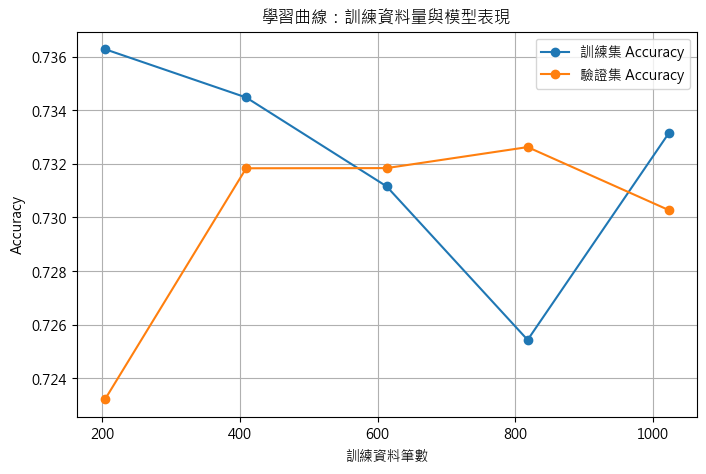

,訓練資料筆數,訓練集 Accuracy 平均,驗證集 Accuracy 平均
0,204,0.736275,0.723214
1,409,0.734474,0.731832
2,613,0.731158,0.731838
3,818,0.725428,0.732623
4,1023,0.733138,0.730273


In [7]:

# ============================================================
# 7. 使用學習曲線觀察模型擬合狀況
# ============================================================

# 建立分層 K 折交叉驗證
# 分層的意思是：每一折都盡量維持原本的類別比例
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

# 設定不同訓練資料比例
train_sizes = np.linspace(0.2, 1.0, 5)

# 計算學習曲線
train_sizes_abs, train_scores, validation_scores = learning_curve(
    estimator=model_pipeline,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy"
)

# 計算每一種訓練資料量下的平均分數
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

# 繪製學習曲線
plt.figure(figsize=(8, 5))
plt.plot(train_sizes_abs, train_mean, marker="o", label="訓練集 Accuracy")
plt.plot(train_sizes_abs, validation_mean, marker="o", label="驗證集 Accuracy")
plt.title("學習曲線：訓練資料量與模型表現")
plt.xlabel("訓練資料筆數")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 顯示表格，方便學生觀察數值
learning_curve_table = pd.DataFrame(
    {
        "訓練資料筆數": train_sizes_abs,
        "訓練集 Accuracy 平均": train_mean,
        "驗證集 Accuracy 平均": validation_mean
    }
)

display(learning_curve_table)



# 8. ROC 曲線與 AUC

原教材介紹 P-R 曲線與 ROC 曲線。本作業選擇 ROC 曲線作為代表性實作。

## ROC 曲線

ROC 曲線的橫軸是 FPR，縱軸是 TPR。

\[
TPR = \frac{TP}{TP + FN}
\]

\[
FPR = \frac{FP}{FP + TN}
\]

## AUC

AUC 是 ROC 曲線下方的面積。AUC 越接近 1，代表模型越能把正類與負類分開。

## P-R 曲線補充

P-R 曲線特別常用在「正類很少」的情況，例如詐騙偵測、疾病偵測、罕見事件偵測。本作業的二元類別大致平衡，因此用 ROC 曲線作為代表即可。


測試集 ROC AUC： 0.8274


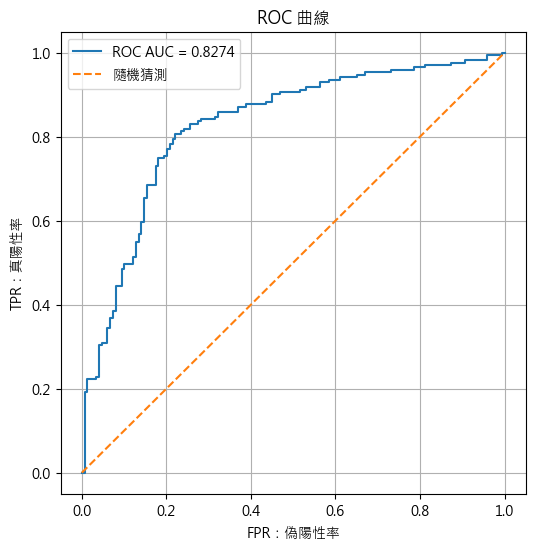

In [8]:

# ============================================================
# 8. ROC 曲線與 AUC
# ============================================================

# predict_proba() 會輸出每個類別的預測機率
# [:, 1] 代表取出模型預測為 good_quality = 1 的機率
test_score = model_pipeline.predict_proba(X_test)[:, 1]

# 計算 ROC 曲線需要的 FPR 與 TPR
fpr, tpr, thresholds = roc_curve(y_test, test_score)

# 計算 AUC
auc_value = roc_auc_score(y_test, test_score)

print("測試集 ROC AUC：", round(auc_value, 4))

# 繪製 ROC 曲線
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC AUC = " + str(round(auc_value, 4)))
plt.plot([0, 1], [0, 1], linestyle="--", label="隨機猜測")
plt.title("ROC 曲線")
plt.xlabel("FPR：偽陽性率")
plt.ylabel("TPR：真陽性率")
plt.legend()
plt.grid(True)
plt.show()



# 9. 超參數調校：使用 GridSearchCV

原教材介紹三種超參數調校方式：

| 方法 | 說明 | 本作業是否實作 |
|---|---|---|
| 手動調整超參數 | 自己設定幾組參數，逐一訓練與比較 | 提到概念，不實作 |
| Grid Search | 把指定範圍內的所有組合都試過 | 實作 |
| Randomized Search | 從指定範圍內隨機抽取固定數量的組合 | 提到概念，不實作 |

本作業選擇 `GridSearchCV`，因為它最適合教學展示「系統化比較超參數組合」。

## 本作業調整兩個超參數

1. `select__k`：選幾個特徵
2. `model__C`：Logistic Regression 的正則化強度

在 Logistic Regression 中，`C` 越小，正則化越強；`C` 越大，正則化越弱。


In [9]:

# ============================================================
# 9. 使用 GridSearchCV 調整超參數
# ============================================================

# 建立要搜尋的超參數範圍
# select__k：對應 Pipeline 裡面名稱為 select 的步驟
# model__C：對應 Pipeline 裡面名稱為 model 的步驟
param_grid = {
    "select__k": [3, 5, 8, 11],
    "model__C": np.linspace(0.1, 5.0, 10)
}

# 建立 GridSearchCV
# scoring="accuracy" 表示用 Accuracy 選出最佳超參數組合
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=1,
    return_train_score=True
)

# 只使用訓練集做超參數搜尋
# 測試集仍然保留到最後評估
grid_search.fit(X_train, y_train)

print("最佳交叉驗證 Accuracy：", round(grid_search.best_score_, 4))
print("最佳超參數：")
print(grid_search.best_params_)

# 將搜尋結果整理成表格
search_results = pd.DataFrame(grid_search.cv_results_)
search_results = search_results.sort_values("rank_test_score")

# 顯示前 10 名組合
result_columns = [
    "rank_test_score",
    "param_select__k",
    "param_model__C",
    "mean_train_score",
    "mean_test_score"
]

display(search_results[result_columns].head(10))


最佳交叉驗證 Accuracy： 0.7389
最佳超參數：
{'model__C': np.float64(1.188888888888889), 'select__k': 11}


,rank_test_score,param_select__k,param_model__C,mean_train_score,mean_test_score
15,1,11,1.733333,0.742377,0.738882
11,1,11,1.188889,0.741791,0.738882
23,1,11,2.822222,0.742377,0.738882
19,1,11,2.277778,0.742377,0.738882
27,1,11,3.366667,0.742377,0.738882
31,1,11,3.911111,0.742377,0.738882
39,1,11,5.000000,0.742377,0.738882
35,1,11,4.455556,0.742377,0.738882
2,9,8,0.100000,0.739642,0.737307
7,10,11,0.644444,0.741009,0.736538



# 10. 使用最佳模型評估測試集

`GridSearchCV` 會自動保存最佳超參數組合對應的模型。

我們要用測試集檢查：

1. 調整超參數後，測試集 Accuracy 是否提升？
2. 調整超參數後，ROC AUC 是否提升？
3. 最佳模型是否真的比原本固定參數的 Pipeline 更好？

請注意：

測試集只應該在最後評估使用，不應該用來反覆挑選超參數。


Grid Search 後測試集 Accuracy： 0.7688
Grid Search 後測試集 ROC AUC： 0.8199


,模型,測試集 Accuracy,測試集 ROC AUC
0,原始 Pipeline,0.784375,0.827387
1,Grid Search 後 Pipeline,0.768750,0.819930


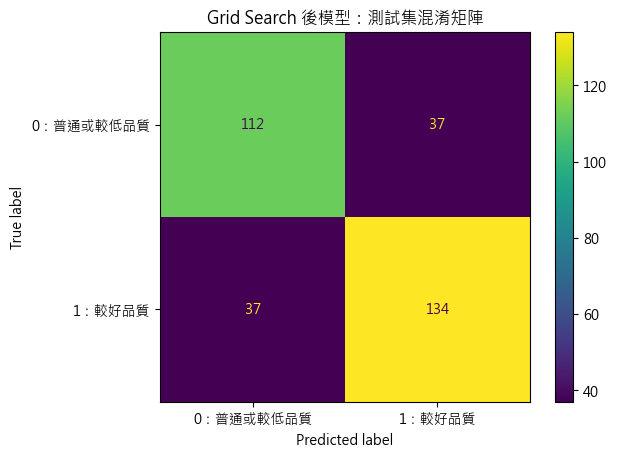

In [10]:

# ============================================================
# 10. 使用最佳模型評估測試集
# ============================================================

# 取得 GridSearchCV 找到的最佳模型
best_model = grid_search.best_estimator_

# 在測試集上預測
tuned_test_pred = best_model.predict(X_test)
tuned_test_score = best_model.predict_proba(X_test)[:, 1]

# 計算調校後模型的測試集分數
tuned_test_accuracy = accuracy_score(y_test, tuned_test_pred)
tuned_auc_value = roc_auc_score(y_test, tuned_test_score)

print("Grid Search 後測試集 Accuracy：", round(tuned_test_accuracy, 4))
print("Grid Search 後測試集 ROC AUC：", round(tuned_auc_value, 4))

# 比較調校前與調校後的結果
score_table = pd.DataFrame(
    {
        "模型": ["原始 Pipeline", "Grid Search 後 Pipeline"],
        "測試集 Accuracy": [test_accuracy, tuned_test_accuracy],
        "測試集 ROC AUC": [auc_value, tuned_auc_value]
    }
)

display(score_table)

# 繪製調校後模型的混淆矩陣
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["0：普通或較低品質", "1：較好品質"]
)
plt.title("Grid Search 後模型：測試集混淆矩陣")
plt.show()



# 11. 作業繳交問題

請在下方新增 Markdown cell，回答以下問題。

## 問題 1：資料與目標

本作業如何把原本的 `quality` 轉成二元分類目標？這樣轉換的好處是什麼？

## 問題 2：Pipeline

本作業的 Pipeline 包含哪三個步驟？每一個步驟的功能是什麼？

## 問題 3：模型評估

請根據 Accuracy 與混淆矩陣，說明模型比較容易犯哪一類錯誤。

## 問題 4：過擬合與欠擬合

觀察學習曲線後，你認為模型比較接近下列哪一種情況？請說明理由。

1. 明顯過擬合
2. 明顯欠擬合
3. 沒有非常明顯的過擬合或欠擬合

## 問題 5：超參數調校

Grid Search 後的模型是否比原始 Pipeline 更好？請根據測試集 Accuracy 與 ROC AUC 說明。

## 延伸思考

如果今天資料的正類非常少，例如只有 5% 是 `good_quality = 1`，你會比較想看 Accuracy、ROC 曲線，還是 P-R 曲線？為什麼？
